Iter    0  beta[0]=0.1000  beta[-1]=0.1082  avg cost=-0.2300
Iter   20  beta[0]=0.1000  beta[-1]=0.2825  avg cost=-0.2367
Iter   40  beta[0]=0.1000  beta[-1]=0.4539  avg cost=-0.2567
Iter   60  beta[0]=0.1000  beta[-1]=0.6160  avg cost=-0.2433
Iter   80  beta[0]=0.1000  beta[-1]=0.7794  avg cost=-0.2800
Iter  100  beta[0]=0.1000  beta[-1]=0.9326  avg cost=-0.3100
Iter  120  beta[0]=0.1000  beta[-1]=1.0772  avg cost=-0.4067
Iter  140  beta[0]=0.1000  beta[-1]=1.2183  avg cost=-0.3533
Iter  160  beta[0]=0.1000  beta[-1]=1.3520  avg cost=-0.4067
Iter  180  beta[0]=0.1000  beta[-1]=1.4790  avg cost=-0.3733
Iter  200  beta[0]=0.1000  beta[-1]=1.5974  avg cost=-0.4167
Iter  220  beta[0]=0.1000  beta[-1]=1.7080  avg cost=-0.4333
Iter  240  beta[0]=0.1000  beta[-1]=1.8087  avg cost=-0.4567
Iter  260  beta[0]=0.1000  beta[-1]=1.9069  avg cost=-0.4700
Iter  280  beta[0]=0.1000  beta[-1]=1.9990  avg cost=-0.4433
Iter  300  beta[0]=0.1000  beta[-1]=2.0857  avg cost=-0.4800
Iter  320  beta[0]=0.100

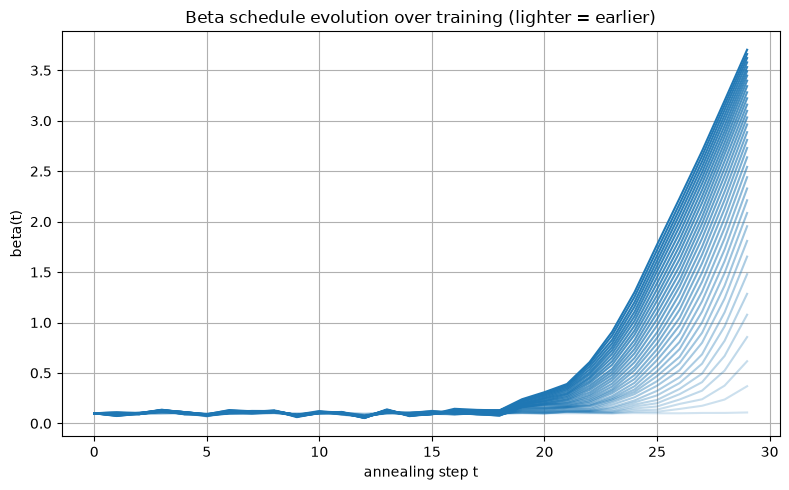

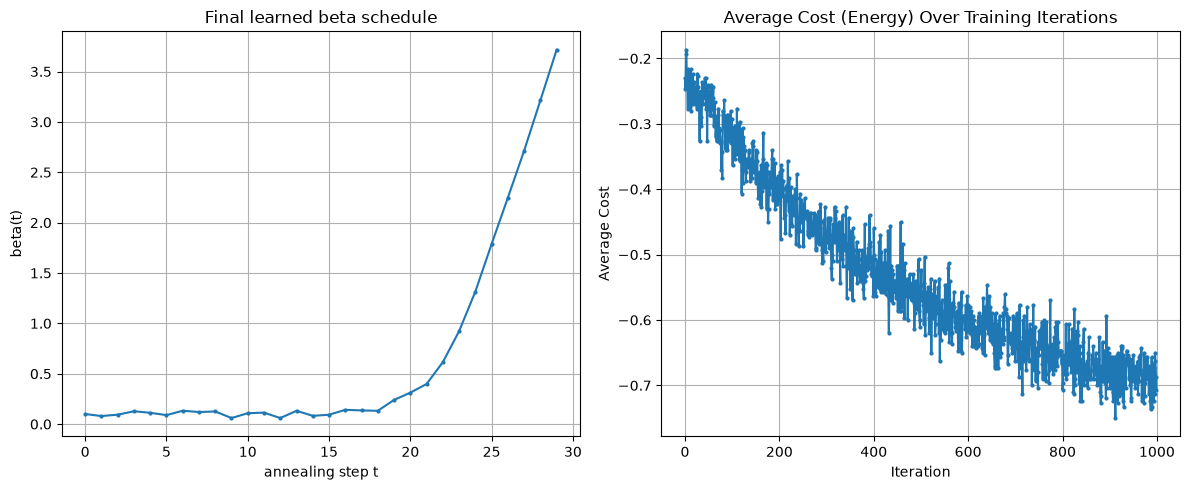

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from Functions import (laydowncoordinates, compute_A, M, Mhat, energy, valid_fold)
from Functions import (generate_all_proposals, generate_legal_neighbors, barker,
                        cost_per_sample, RL_trajectory, grad_expectedcost, update_beta)


def RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps):
    d = d0.copy()
    E_current = cost_per_sample(Gamma, A, H, d)
    grad_logP = np.zeros(num_time_steps)  # per-step gradient, not a scalar

    for t in range(num_time_steps):
        neighbors = generate_legal_neighbors(d)
        if len(neighbors) == 0:
            break

        beta_t = beta_schedule[t]
        j = np.random.randint(len(neighbors))
        d_prime = neighbors[j]
        E_prime = cost_per_sample(Gamma, A, H, d_prime)
        deltaE = E_prime - E_current

        A_accept = barker(deltaE, beta_t)
        u = np.random.uniform(0, 1)
        if u < A_accept:
            grad_logP[t] = -deltaE / (1 + np.exp(-beta_t * deltaE))
            d = d_prime
            E_current = E_prime
        else:
            grad_logP[t] = deltaE / (1 + np.exp(beta_t * deltaE))

    return d, E_current, grad_logP


def grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps=1, num_independent_experiments=10):
    H = 1
    A = compute_A(Gamma)
    costs = np.zeros(num_independent_experiments)
    grad_matrix = np.zeros((num_independent_experiments, num_time_steps))

    for i in range(num_independent_experiments):
        d_final, E_final, grad_logP = RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps)
        costs[i] = E_final
        grad_matrix[i] = grad_logP

    baseline = np.mean(costs)
    grad_beta_schedule = np.mean((costs - baseline)[:, None] * grad_matrix, axis=0)

    return costs, grad_beta_schedule


def update_beta_schedule(beta_schedule, grad_beta_schedule, learning_rate):
    beta_schedule = beta_schedule - learning_rate * grad_beta_schedule
    return np.clip(beta_schedule, 0.0, None)


H = 1
P = 0
# Gamma = [P, P, H, P, H, P, P, P, P, H, P, H, H, P, H, P]  # 16-bead sequence
# d0 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Gamma = [H,P,P,H]  # 16-bead sequence
d0 = [1, 1, 1]

num_time_steps = 30
num_independent_experiments = 300
learning_rate = 0.1
num_iterations = 1000

cost_history = []
schedule_snapshots = []
snapshot_every = 30

beta_schedule = np.full(num_time_steps, 0.1)  # initialize BEFORE the loop

for iteration in range(num_iterations):
    costs, grad = grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps, num_independent_experiments)
    beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
    cost_history.append(np.mean(costs))

    if iteration % snapshot_every == 0:
        schedule_snapshots.append(beta_schedule.copy())

    if iteration % 20 == 0:
        print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
              f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={np.mean(costs):.4f}")


# schedule evolution over training
plt.figure(figsize=(8, 5))
for i, snap in enumerate(schedule_snapshots):
    alpha = 0.2 + 0.8 * (i / max(len(schedule_snapshots) - 1, 1))
    plt.plot(snap, color='C0', alpha=alpha)
plt.xlabel("annealing step t")
plt.ylabel("beta(t)")
plt.title("Beta schedule evolution over training (lighter = earlier)")
plt.grid(True)
plt.tight_layout()
plt.show()

# final schedule + cost convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_schedule, marker='o', markersize=2)
axes[0].set_title("Final learned beta schedule")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].grid(True)

axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost (Energy) Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Iter    0  beta[0]=0.1000  beta[-1]=0.1034  avg cost=-0.1310
Iter   20  beta[0]=0.1000  beta[-1]=0.1775  avg cost=-0.1170
Iter   40  beta[0]=0.1000  beta[-1]=0.2530  avg cost=-0.1460
Iter   60  beta[0]=0.1000  beta[-1]=0.3248  avg cost=-0.1320
Iter   80  beta[0]=0.1000  beta[-1]=0.3995  avg cost=-0.1400
Iter  100  beta[0]=0.1000  beta[-1]=0.4750  avg cost=-0.1450
Iter  120  beta[0]=0.1000  beta[-1]=0.5459  avg cost=-0.1740
Iter  140  beta[0]=0.1000  beta[-1]=0.6177  avg cost=-0.1800
Iter  160  beta[0]=0.1000  beta[-1]=0.6904  avg cost=-0.1730
Iter  180  beta[0]=0.1000  beta[-1]=0.7594  avg cost=-0.1880
Iter  200  beta[0]=0.1000  beta[-1]=0.8306  avg cost=-0.1850
Iter  220  beta[0]=0.1000  beta[-1]=0.8958  avg cost=-0.1840
Iter  240  beta[0]=0.1000  beta[-1]=0.9613  avg cost=-0.1830
Iter  260  beta[0]=0.1000  beta[-1]=1.0282  avg cost=-0.2200
Iter  280  beta[0]=0.1000  beta[-1]=1.0936  avg cost=-0.1860
Iter  300  beta[0]=0.1000  beta[-1]=1.1564  avg cost=-0.2180
Iter  320  beta[0]=0.100

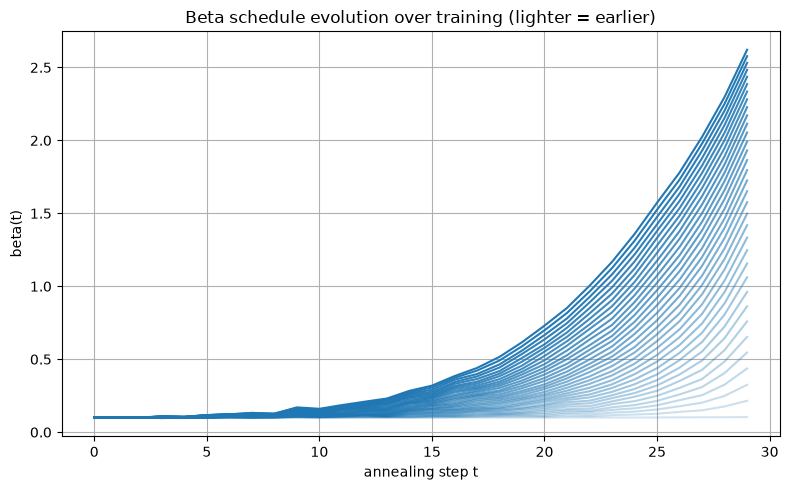

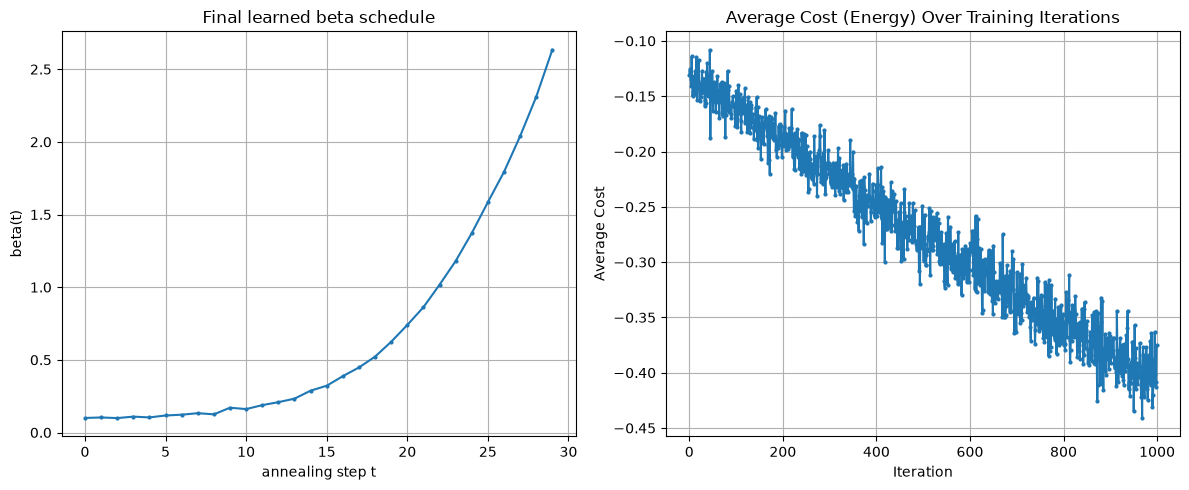

In [ ]:
#Joblib-parallelized RL annealing schedule

import os
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from Functions import (laydowncoordinates, compute_A, M, Mhat, energy, valid_fold)
from Functions import (generate_all_proposals, generate_legal_neighbors, barker,
                        cost_per_sample, RL_trajectory, grad_expectedcost, update_beta)


H = 1
P = 0
Gamma = [H, H, P, P, H, P, H]  # 16-bead sequence
d0 = [1, 1, 1, 1, 1, 1]

num_time_steps = 30
num_independent_experiments = 1000
learning_rate = 0.1
num_iterations = 1000
cost_history = []
schedule_snapshots = []
snapshot_every = 30
n_jobs = -1  

beta_schedule = np.full(num_time_steps, 0.1)

for iteration in range(num_iterations):
    costs, grad = grad_expectedcost_schedule(
        d0, Gamma, beta_schedule, num_time_steps,
        num_independent_experiments, n_jobs=n_jobs,
    )
    beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
    cost_history.append(np.mean(costs))
    if iteration % snapshot_every == 0:
        schedule_snapshots.append(beta_schedule.copy())
    if iteration % 20 == 0:
        print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
              f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={np.mean(costs):.4f}")


plt.figure(figsize=(8, 5))
for i, snap in enumerate(schedule_snapshots):
    alpha = 0.2 + 0.8 * (i / max(len(schedule_snapshots) - 1, 1))
    plt.plot(snap, color='C0', alpha=alpha)
plt.xlabel("annealing step t")
plt.ylabel("beta(t)")
plt.title("Beta schedule evolution over training (lighter = earlier)")
plt.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_schedule, marker='o', markersize=2)
axes[0].set_title("Final learned beta schedule")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].grid(True)
axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost (Energy) Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)
plt.tight_layout()
plt.show()

Iter    0  beta[0]=0.0913  beta[-1]=0.1305  avg cost=-0.3600
Iter   20  beta[0]=0.0096  beta[-1]=0.9121  avg cost=-0.6200
Iter   40  beta[0]=0.0258  beta[-1]=2.0598  avg cost=-1.5200
Iter   60  beta[0]=0.2037  beta[-1]=2.9887  avg cost=-1.8200
Iter   80  beta[0]=0.3162  beta[-1]=3.5705  avg cost=-1.8400
Iter  100  beta[0]=0.2714  beta[-1]=3.9324  avg cost=-1.9800
Iter  120  beta[0]=0.2553  beta[-1]=4.1427  avg cost=-2.0000
Iter  140  beta[0]=0.2061  beta[-1]=4.2874  avg cost=-2.0800
Iter  160  beta[0]=0.7296  beta[-1]=4.4080  avg cost=-2.2600
Iter  180  beta[0]=0.6960  beta[-1]=4.5025  avg cost=-2.4000
Iter  200  beta[0]=0.8843  beta[-1]=4.6504  avg cost=-2.2000
Iter  220  beta[0]=0.9747  beta[-1]=4.8029  avg cost=-2.4600
Iter  240  beta[0]=0.8446  beta[-1]=4.9662  avg cost=-2.4400
Iter  260  beta[0]=0.6583  beta[-1]=5.1721  avg cost=-2.4800
Iter  280  beta[0]=0.7569  beta[-1]=5.1996  avg cost=-2.4400
Iter  300  beta[0]=1.2771  beta[-1]=5.2729  avg cost=-2.5600
Iter  320  beta[0]=1.691

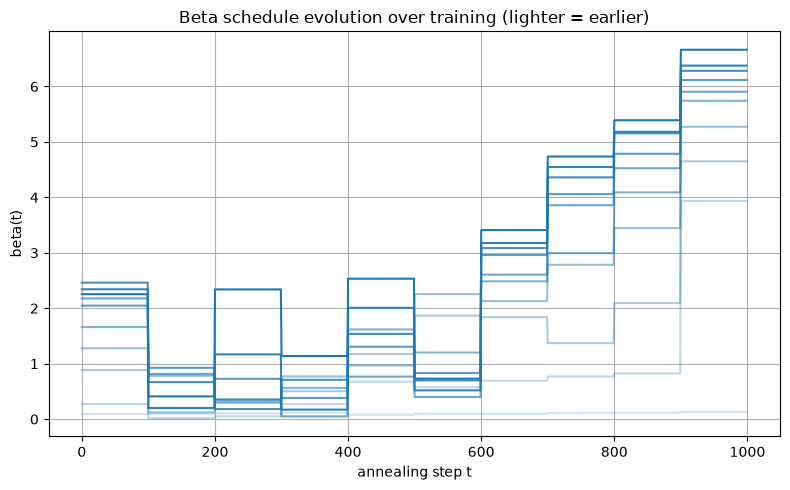

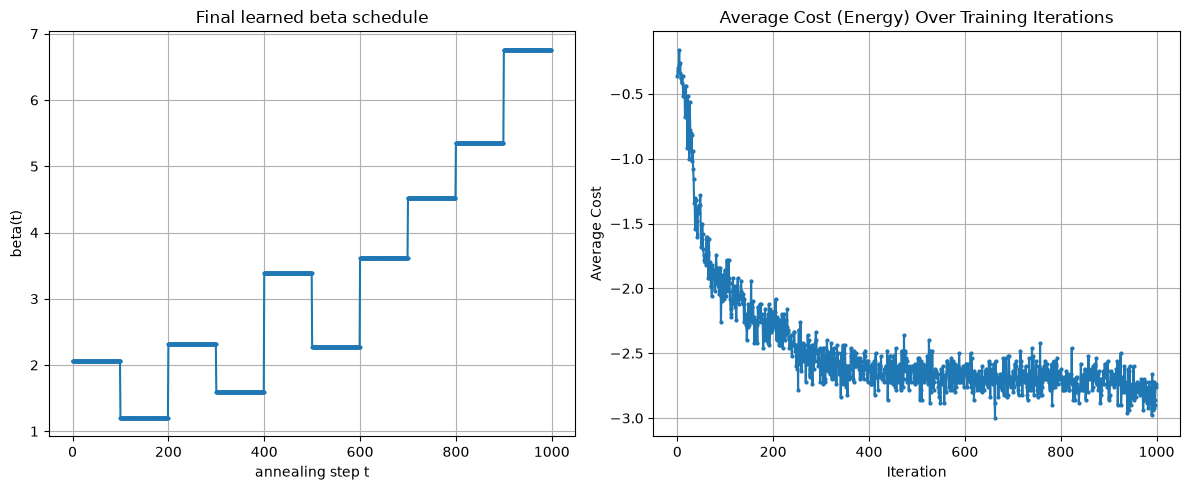

In [10]:
#joblib stairs
from joblib import Parallel, delayed

def RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps):
    d = d0.copy()
    E_current = cost_per_sample(Gamma, A, H, d)
    grad_logP = np.zeros(num_blocks)

    for t in range(num_time_steps):
        neighbors = generate_legal_neighbors(d)
        if len(neighbors) == 0:
            break

        block = t // block_size
        beta_t = beta_schedule[block]
        j = np.random.randint(len(neighbors))
        d_prime = neighbors[j]
        E_prime = cost_per_sample(Gamma, A, H, d_prime)
        deltaE = E_prime - E_current

        A_accept = barker(deltaE, beta_t)
        u = np.random.uniform(0, 1)
        if u < A_accept:
            grad_logP[block] += -deltaE / (1 + np.exp(-beta_t * deltaE))
            d, E_current = d_prime, E_prime
        else:
            grad_logP[block] += deltaE / (1 + np.exp(beta_t * deltaE))

    return d, E_current, grad_logP

def run_experiment(d0, Gamma, A, H, beta_schedule, num_time_steps):
    _, E_final, grad_logP = RL_trajectory_schedule(
        d0, Gamma, A, H, beta_schedule, num_time_steps
    )
    return E_final, grad_logP


def grad_expectedcost_schedule(d0, Gamma, beta_schedule,num_time_steps, num_independent_experiments):
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment)(
            d0, Gamma, A, H, beta_schedule, num_time_steps)
        for _ in range(num_independent_experiments)
    )

    costs = np.zeros(num_independent_experiments)
    grad_beta_schedule = np.zeros(num_blocks)

    for i, (E_final, grad_logP) in enumerate(results):
        costs[i] = E_final
        grad_beta_schedule += E_final * grad_logP

    grad_beta_schedule /= num_independent_experiments

    return costs, grad_beta_schedule


def update_beta_schedule(beta_schedule, grad_beta_schedule, learning_rate):
    beta_schedule = beta_schedule - learning_rate * grad_beta_schedule
    return np.clip(beta_schedule, 0.0, None)




H = 1
P = 0
Gamma = [P, P, H, P, H, P, P, P, P, H, P, H, H, P, H, P]  # 16-bead sequence
d0 = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

num_time_steps = 1000
num_independent_experiments = 50
learning_rate = 0.1
num_iterations = 1000
block_size = 100
num_blocks = num_time_steps // block_size

cost_history = []
schedule_snapshots = []
snapshot_every = 100

beta_schedule = np.full(num_blocks, 0.1)

for iteration in range(num_iterations):
    costs, grad = grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps, num_independent_experiments)
    beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
    cost_history.append(np.mean(costs))
    #record the schedule after each run
    if iteration % snapshot_every == 0:
        schedule_snapshots.append(beta_schedule.copy())

    if iteration % 20 == 0:
        print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
              f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={np.mean(costs):.4f}")


# schedule evolution over training
plt.figure(figsize=(8, 5))
for i, snap in enumerate(schedule_snapshots):
    alpha = 0.2 + 0.8 * (i / max(len(schedule_snapshots) - 1, 1))
    plt.plot(np.repeat(snap, block_size), color='C0', alpha=alpha)
plt.xlabel("annealing step t")
plt.ylabel("beta(t)")
plt.title("Beta schedule evolution over training (lighter = earlier)")
plt.grid(True)
plt.tight_layout()
plt.show()

# final schedule + cost convergence

beta_full = np.repeat(beta_schedule, block_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_full, marker='o', markersize=2)
axes[0].set_title("Final learned beta schedule")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].grid(True)

axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost (Energy) Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)

plt.tight_layout()
plt.show()

